In [1]:
# CARGA DE DATOS #

import pandas as pd

# Ruta al archivo de Excel
archivo_excel = './IIYNT-REQ-BD-003.xlsx' #../

# Número de la fila desde la cual querés empezar (0-indexado)
fila_inicio = 3

# Leer el archivo Excel
init_df = pd.read_excel(archivo_excel)

# Mostrar las primeras filas del DataFrame para confirmar que se leyó bien
init_df.head()

# TRANSFORMACIÓN DE DATOS #

desired_columns = [
    'Temperatura Ambiental (°C)', 
    'Humedad',
    'Temperatura de la muestra (°C)', 
    'pH', 
    'CE\n(µS/cm)', 
    'STD\n(mg/L)',
    'STS\n(mL sed/L)', 
    'OD\n(mg/L)', 
    'Nivel (cm)', 
    'Turbidez (NTU)',
    'Dureza\n(mg CaCO3/L)', 
    'Cloruros\n(mg Cl-/L)'
]
df = init_df.iloc[2:123][desired_columns]
df


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
2,16,0.929,18,8.2,1240,610,NaN,5.37,NaN,NaN,NaN,NaN
3,17,0.47,19,8.3,1630,810,1.8,4.3,NaN,NaN,147,156
4,11.9,0.47,13,8.1,1000,490,18,5.3,NaN,41.2,94,78
5,11.9,0.47,13,8.2,1000,490,18,4.67,NaN,38.9,86,82
6,11.9,0.47,13,8.3,1350,670,0.1,7.01,NaN,30.7,200,117
...,...,...,...,...,...,...,...,...,...,...,...,...
118,12.8,0.57,15.3,8,1110,550,18,4.18,25,5.04,316,66
119,12.8,0.57,15.3,8.1,1080,550,18,4.23,25,5.69,316,66
120,12.8,0.57,15.4,8.4,1050,520,44,1.96,70,113,146,82
121,12.8,0.57,15.4,8.4,1070,530,44,1.67,70,133,146,82


In [2]:

#ver los que tienen valores nulos o no asignados

#df.isnull().sum()
df.isna().sum()

#Eliminar las filas que tienen valores nulos o no asignados
#df.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true

#Si asigno a nueva variable no hace falta inplace=true pero no modifica el Dataframe original
#df_sin_nulos=df.dropna()

#Como opcion puedo llenar los valores nulos con datos adecuados: 
#fillna(method='bfill') (llenar con el valor siguiente de la columna)
#fillna(method='ffill') (llenar con el valor anterior de la columna)
#fillna(0) (llenar con ceros) 

mediaNivel=df['Nivel (cm)'].mean()
df['Nivel (cm)']=df['Nivel (cm)'].fillna(mediaNivel)

mediaSTS=df['STS\n(mL sed/L)'].mean()
df['STS\n(mL sed/L)']=df['STS\n(mL sed/L)'].fillna(mediaSTS)

mediaTurbidez=df['Turbidez (NTU)'].mean()
df['Turbidez (NTU)']=df['Turbidez (NTU)'].fillna(mediaTurbidez)

mediaDureza=df['Dureza\n(mg CaCO3/L)'].mean()
df['Dureza\n(mg CaCO3/L)']=df['Dureza\n(mg CaCO3/L)'].fillna(mediaDureza)

mediaCloruros=df['Cloruros\n(mg Cl-/L)'].mean()
df['Cloruros\n(mg Cl-/L)']=df['Cloruros\n(mg Cl-/L)'].fillna(mediaCloruros)

df_sin_nulos=df.copy()
df_sin_nulos.isna().sum()

#Eliminar las filas que tienen valores nulos o no asignados
df_sin_nulos.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true
df_sin_nulos.isna().sum()

Temperatura Ambiental (°C)        0
Humedad                           0
Temperatura de la muestra (°C)    0
pH                                0
CE\n(µS/cm)                       0
STD\n(mg/L)                       0
STS\n(mL sed/L)                   0
OD\n(mg/L)                        0
Nivel (cm)                        0
Turbidez (NTU)                    0
Dureza\n(mg CaCO3/L)              0
Cloruros\n(mg Cl-/L)              0
dtype: int64

In [3]:
def min_max_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    name = list()
    minimums = list()
    maximums = list()
    for i, key in enumerate(dataframe.columns):
        name.append(key)
        minimums.append(dataframe[key].min())
        maximums.append(dataframe[key].max())
    return pd.DataFrame(
        {
            'name': name,
            'mins': minimums,
            'maxs': maximums
        }
    )
min_max_info(df_sin_nulos)

,name,mins,maxs
0,Temperatura Ambiental (°C),10.40,26.000
1,Humedad,0.36,0.929
2,Temperatura de la muestra (°C),12.80,28.100
3,pH,7.20,8.700
4,CE\n(µS/cm),200.00,1690.000
5,STD\n(mg/L),140.00,840.000
6,STS\n(mL sed/L),0.10,650.000
7,OD\n(mg/L),0.00,9.120
8,Nivel (cm),20.00,70.000
9,Turbidez (NTU),2.68,1000.000


In [4]:
def normalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return (dataframe - min) / (max - min)

def denormalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return dataframe * (max - min) + min


def normalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = normalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = normalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = normalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = normalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = normalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = normalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = normalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = normalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = normalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = normalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = normalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df

def denormalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = denormalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = denormalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = denormalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = denormalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = denormalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = denormalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = denormalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = denormalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = denormalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = denormalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = denormalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df




In [5]:
from keras.layers import Input, Dense
from keras.activations import sigmoid
from keras.losses import mse
from keras.models import Model
import numpy as np

vector_size = len(df_sin_nulos.columns)
dataset = np.array(normalizer(df_sin_nulos).astype(np.float16))
encoded_size = 3
# definimos modelo:
input_v = Input(shape=(vector_size, ))
x = Dense(4, activation=sigmoid)(input_v)
encoded = Dense(encoded_size, activation=sigmoid)(x)
x = Dense(4, activation=sigmoid)(encoded)
output = Dense(vector_size, activation=sigmoid)(x)

autoencoder = Model(input_v, output)
autoencoder.compile(optimizer='adam', loss=mse)
autoencoder.summary()


2023-09-24 21:33:23.179059: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-09-24 21:33:23.181118: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-09-24 21:33:23.249200: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-09-24 21:33:23.254835: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-09-24 21:33:24.479862: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense (Dense)               (None, 4)                 52        
                                                                 
 dense_1 (Dense)             (None, 3)                 15        
                                                                 
 dense_2 (Dense)             (None, 4)                 16        
                                                                 
 dense_3 (Dense)             (None, 12)                60        
                                                                 
Total params: 143 (572.00 Byte)
Trainable params: 143 (572.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [34]:
autoencoder.fit(
    x=dataset,
    y=dataset,
    epochs=500,
    batch_size=120,
    shuffle=True
)


Epoch 1/500
1/1 [==============================] - 0s 6ms/step - loss: 0.0039
Epoch 2/500
1/1 [==============================] - 0s 3ms/step - loss: 0.0039
Epoch 3/500
1/1 [==============================] - 0s 3ms/step - loss: 0.0039
Epoch 4/500
1/1 [==============================] - 0s 5ms/step - loss: 0.0039
Epoch 5/500
1/1 [==============================] - 0s 3ms/step - loss: 0.0039
Epoch 6/500
1/1 [==============================] - 0s 3ms/step - loss: 0.0039
Epoch 7/500
1/1 [==============================] - 0s 5ms/step - loss: 0.0039
Epoch 8/500
1/1 [==============================] - 0s 3ms/step - loss: 0.0039
Epoch 9/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0039
Epoch 10/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0039
Epoch 11/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0039
Epoch 12/500
1/1 [==============================] - 0s 4ms/step - loss: 0.0039
Epoch 13/500
1/1 [==============================] - 0s 4ms/st

In [35]:
generator = Model(encoded, output)
generator.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 3)]               0         
                                                                 
 dense_2 (Dense)             (None, 4)                 16        
                                                                 
 dense_3 (Dense)             (None, 12)                60        
                                                                 
Total params: 76 (304.00 Byte)
Trainable params: 76 (304.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [36]:
amount = 500
generated = np.zeros(shape=(amount, vector_size))
params = np.random.rand(amount, encoded_size)
generated = generator.predict(params)


16/16 [==============================] - 0s 810us/step


In [37]:
gen_df = pd.DataFrame(generated)
gen_df.columns = df_sin_nulos.columns
gen_df = denormalizer(gen_df)
gen_df

,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
0,19.617891,0.098545,22.144131,7.623169,1198.605957,590.504089,292.827209,0.598629,29.280270,906.330811,241.520889,62.104637
1,22.502644,0.926915,15.726435,7.631178,1790.706421,894.390015,682.266541,2.792236,22.570581,987.927124,149.102844,171.014526
2,17.596128,0.669190,17.391375,8.166514,1461.258667,722.547913,58.590740,1.673530,45.363583,103.146172,169.866425,124.542030
3,22.308092,0.898640,16.384987,7.776426,1850.278320,925.157410,602.177368,1.849438,28.450594,941.314453,166.997925,178.794205
4,20.848017,0.954083,15.044909,8.134893,1852.764038,926.098572,208.517380,1.688278,44.558800,306.135315,143.529144,183.681946
...,...,...,...,...,...,...,...,...,...,...,...,...
495,22.928059,0.662229,18.815443,7.462269,1453.958130,719.351929,518.918884,0.729752,27.823246,991.506897,158.203522,110.841049
496,19.426027,0.960868,14.297432,8.128644,1661.258423,826.070801,99.856026,2.685980,43.804352,288.493073,121.305008,163.739639
497,15.444822,0.947766,13.266575,8.312467,1431.286011,707.189758,41.984890,7.046962,36.335545,86.855904,125.709991,140.466171
498,19.804783,0.823478,16.921036,8.020864,1507.828857,746.212036,88.847237,1.007998,47.208057,321.144867,143.028595,134.105942


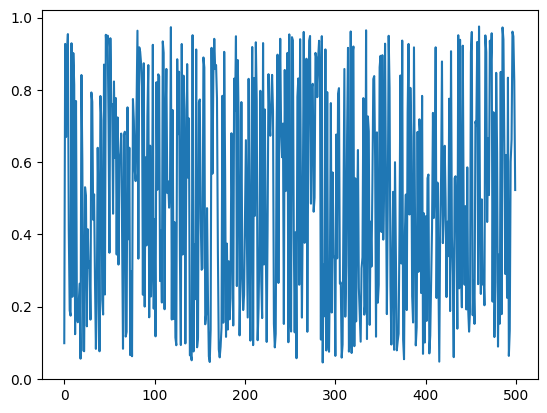

In [38]:
from matplotlib.pyplot import plot
plotable = np.array(gen_df)
plot(plotable.T[1])

In [39]:
min_max_info(df_sin_nulos)

,name,mins,maxs
0,Temperatura Ambiental (°C),10.40,26.000
1,Humedad,0.36,0.929
2,Temperatura de la muestra (°C),12.80,28.100
3,pH,7.20,8.700
4,CE\n(µS/cm),200.00,1690.000
5,STD\n(mg/L),140.00,840.000
6,STS\n(mL sed/L),0.10,650.000
7,OD\n(mg/L),0.00,9.120
8,Nivel (cm),20.00,70.000
9,Turbidez (NTU),2.68,1000.000


In [40]:
min_max_info(gen_df)

,name,mins,maxs
0,Temperatura Ambiental (°C),10.147751,25.482128
1,Humedad,0.045138,0.975197
2,Temperatura de la muestra (°C),12.803101,23.064480
3,pH,7.269817,8.565899
4,CE\n(µS/cm),305.358643,1924.114990
5,STD\n(mg/L),179.258026,962.859009
6,STS\n(mL sed/L),5.364423,766.311218
7,OD\n(mg/L),0.038546,9.453783
8,Nivel (cm),15.410810,58.420979
9,Turbidez (NTU),8.600564,998.362427
